In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap

from watobs import CMEMSSatObsRepository

import copernicusmarine

# First time users
First time users of the Copernicus Marine API will need to create an account at https://marine.copernicus.eu/ and generate an API key.

Below you call the login function to authenticate your credentials. You only have to do this the first time you use the API on a PC.



In [2]:
if not CMEMSSatObsRepository.validate_login():
    copernicusmarine.login()

### Specify dataset of product to be downloaded from CMEMS Online Catalogue
- Click through the catalogue here: https://data.marine.copernicus.eu/products?pk_vid=bfd50509683fc0421764148768aca348 

In [3]:
# In this case, I am intersted in wind speeds from the product 'WIND_GLO_PHY_L3_NRT_012_002'

# Entering my product ID for copernicusmiarine to search for available datasets
# Note, this search string could also be e.g. '_swh_' if you want to see which datasets are available with significant wave heights.
'''search_str = 'WIND_GLO_PHY_L3_NRT_012_002'


catalogue = copernicusmarine.describe(contains=[search_str])
product = catalogue.products[-1]
sat_sets = product.datasets
dataset_ids = [sat_sets[i].dataset_id for i in range(len(sat_sets))]'''

"search_str = 'WIND_GLO_PHY_L3_NRT_012_002'\n\n\ncatalogue = copernicusmarine.describe(contains=[search_str])\nproduct = catalogue.products[-1]\nsat_sets = product.datasets\ndataset_ids = [sat_sets[i].dataset_id for i in range(len(sat_sets))]"

### Datasets from product WIND_GLO_PHY_L3_NRT_012_002
- A total of 32 datasets, i.e. data from 32 different satellite missions

In [4]:
# len(dataset_ids)

# Lets just choose the first satellite mission for simplicity
- In this case, i am interested in data from 2019 only
- In addition i want to see data in the North Sea west of the Danish coastline

In [5]:
# dataset = dataset_ids[0]
dataset = 'cmems_obs-wind_glo_phy_nrt_l3-hy2b-hscat-asc-0.25deg_P1D-i'
start_year = 2021
end_year = 2021

lon_min = 6
lon_max = 9
lat_min = 55
lat_max = 57.5

area = f"bbox={lon_min},{lat_min},{lon_max},{lat_max}"

In [6]:
repo = CMEMSSatObsRepository()

In [7]:
df = repo.download_copernicus_data(dataset_id=dataset,
                                                    start_time="2021-01-01",
                                                    #end_time="2021-12-31",
                                                    end_time="2021-01-31",
                                                    area = area)

-- Downloading subset of cmems_obs-wind_glo_phy_nrt_l3-hy2b-hscat-asc-0.25deg_P1D-i


INFO - 2025-12-01T09:39:44Z - Selected dataset version: "202311"
INFO - 2025-12-01T09:39:44Z - Selected dataset part: "default"
INFO - 2025-12-01T09:39:49Z - Starting download. Please wait...
INFO - 2025-12-01T09:39:57Z - Successfully downloaded to c:\Working\Coding\Repos\watobs\notebooks\cmems_ghcgiexs\cmems_obs-wind_glo_phy_nrt_l3-hy2b-hscat-asc-0.25deg_P1D-i_multi-vars_6.12E-8.88E_55.12N-57.38N_2021-01-01-2021-01-31.nc


-- Download successful.


### Data downloaded
- And it took 25-30 seconds for a year worth of wind speeds, directions and vector components

In [8]:
df

,longitude,latitude,WS,WD,U10,V10
time,,,,,,
2021-01-01 16:12:48,6.125,55.125,6.13,135.4,4.27,-4.36
2021-01-01 16:12:48,6.375,55.125,5.61,126.2,4.46,-3.31
2021-01-01 16:12:48,6.625,55.125,5.28,118.3,4.61,-2.49
2021-01-01 16:12:48,6.875,55.125,4.86,112.8,4.42,-1.84
2021-01-01 16:12:48,7.125,55.125,4.51,146.1,3.30,-0.56
...,...,...,...,...,...,...
2021-01-31 16:58:40,7.875,57.375,4.79,104.2,4.50,-1.08
2021-01-31 16:58:40,8.125,57.375,-327.67,-3276.7,-327.67,-327.67
2021-01-31 16:58:40,8.375,57.375,-327.67,-3276.7,-327.67,-327.67


### Plotting
- Lets plot and see the data

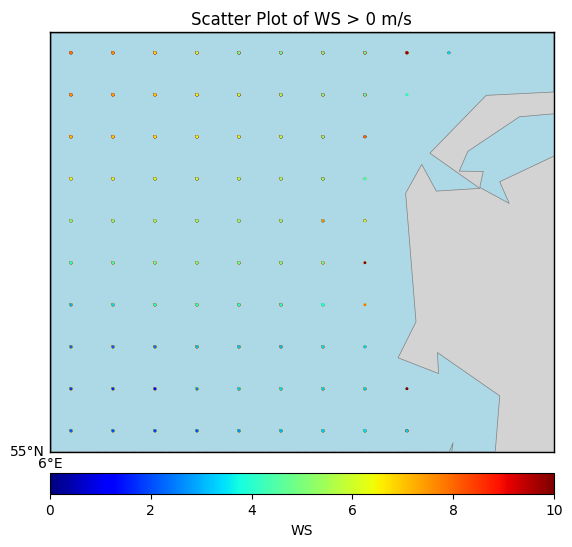

In [ ]:
# Define bounding box
dxm = 20
lon_0 = 0.5 * (lon_min + lon_max)
lat_0 = 0.5 * (lat_min + lat_max)

plt.figure(figsize=(10, 6))

# Initialize Basemap
m = Basemap(projection='cyl',
            lon_0=lon_0, lat_0=lat_0,
            llcrnrlon=lon_min, llcrnrlat=lat_min,
            urcrnrlon=lon_max, urcrnrlat=lat_max,
            resolution='l')

# Draw map features
m.drawcoastlines(color='gray', linewidth=0.5)
m.fillcontinents(color='lightgray', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')

# Draw parallels and meridians
m.drawparallels(np.arange(lat_min, lat_max + dxm, dxm),
                labels=[1, 0, 0, 0], linewidth=0.5, color='lightgray', dashes=[2, 2])
m.drawmeridians(np.arange(lon_min, lon_max + dxm, dxm),
                labels=[0, 0, 0, 1], linewidth=0.5, color='lightgray', dashes=[2, 2])

# Prepare coordinates
x, y = m(df['longitude'].values, df['latitude'].values)

# Create alpha mask: transparent if WS == 0.5
alpha_values = np.where(df['WS'] < 0.01, 0.0, 1.0)

# Scatter plot with alpha mask
cs = m.scatter(x, y, c=df['WS'], s=1, marker='o',
    cmap=plt.cm.jet, vmin=0, vmax=10,
    alpha=alpha_values)

# Colorbar
cbar = m.colorbar(cs, location='bottom', pad="5%")
cbar.set_label('WS')

plt.title('Scatter Plot of WS > 0 m/s')
plt.show()

In [ ]:
df = repo.download_copernicus_data(dataset_id=dataset,
                                                    start_time="2021-01-01",
                                                    end_time="2021-12-31")

- Downloading January 2021


INFO - 2025-12-01T09:40:03Z - Selected dataset version: "202311"
INFO - 2025-12-01T09:40:03Z - Selected dataset part: "default"
INFO - 2025-12-01T09:40:04Z - Listing files on remote server...
2it [00:01,  1.30it/s]

In [ ]:
dfdfgdfg

,index,longitude,latitude,WS,WD,U10,V10
time,,,,,,,
2021-01-01 12:00:00,69859,184.875,-77.875,10.30,338.7,-3.76,9.59
2021-01-01 12:03:12,69860,185.125,-77.875,10.44,337.5,-4.00,9.65
2021-01-01 12:03:12,69861,185.375,-77.875,10.19,335.9,-4.13,9.30
2021-01-01 12:03:12,69862,185.625,-77.875,13.47,323.8,-8.00,10.83
2021-01-01 12:03:12,69863,185.875,-77.875,13.46,323.1,-8.09,10.74
...,...,...,...,...,...,...,...
2021-12-31 14:37:52,989362,20.625,81.875,9.64,277.7,-9.56,1.29
2021-12-31 14:37:52,989363,20.875,81.875,8.70,287.5,-8.30,2.61
2021-12-31 14:37:52,989364,21.125,81.875,8.71,287.5,-8.30,2.62


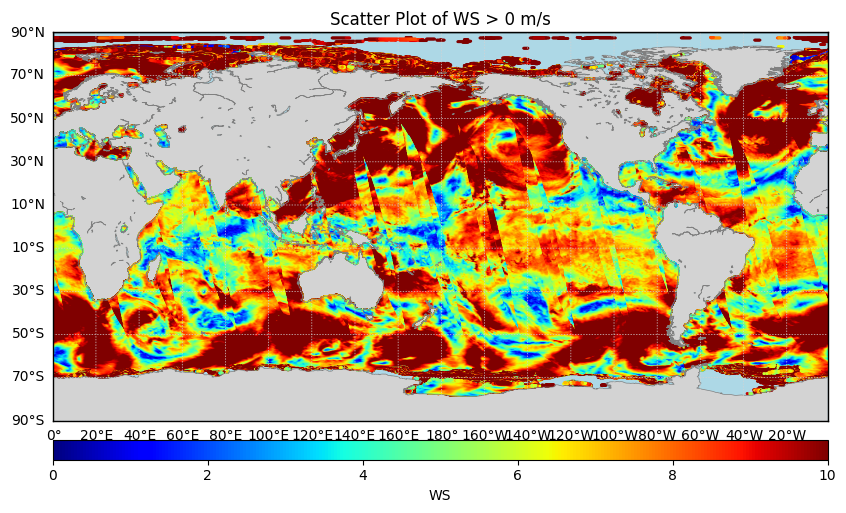

In [ ]:
# Define bounding box
dxm = 20
lon_min = 0
lon_max = 359
lat_min = -90
lat_max = 90
lon_0 = 0.5 * (lon_min + lon_max)
lat_0 = 0.5 * (lat_min + lat_max)

plt.figure(figsize=(10, 6))

# Initialize Basemap
m = Basemap(projection='cyl',
            lon_0=lon_0, lat_0=lat_0,
            llcrnrlon=lon_min, llcrnrlat=lat_min,
            urcrnrlon=lon_max, urcrnrlat=lat_max,
            resolution='l')

# Draw map features
m.drawcoastlines(color='gray', linewidth=0.5)
m.fillcontinents(color='lightgray', lake_color='lightblue')
m.drawmapboundary(fill_color='lightblue')

# Draw parallels and meridians
m.drawparallels(np.arange(lat_min, lat_max + dxm, dxm),
                labels=[1, 0, 0, 0], linewidth=0.5, color='lightgray', dashes=[2, 2])
m.drawmeridians(np.arange(lon_min, lon_max + dxm, dxm),
                labels=[0, 0, 0, 1], linewidth=0.5, color='lightgray', dashes=[2, 2])

# Prepare coordinates
x, y = m(df['longitude'].values, df['latitude'].values)

# Create alpha mask: transparent if WS == 0.5
alpha_values = np.where(df['WS'] < 0.01, 0.0, 1.0)

# Scatter plot with alpha mask
cs = m.scatter(x, y, c=df['WS'], s=1, marker='o',
               cmap=plt.cm.jet, vmin=0, vmax=10,
               alpha=alpha_values)

# Colorbar
cbar = m.colorbar(cs, location='bottom', pad="5%")
cbar.set_label('WS')

plt.title('Scatter Plot of WS > 0 m/s')
plt.show()